## Compare pretrained backbones

In [1]:
from sklearn.model_selection import StratifiedGroupKFold
from configs.cfg import CFG
from dataset.biomass_dataset import *
from utils.augs import *
from configs.deterministic import *
from models.models import *
from train.train import *
from dataset.preprocess_data import *

if __name__ == "__main__":
    set_seed(CFG.SEED,CFG.DETERMINISTIC)
    df_wide = get_df()
    
    fold_indices = {}

    sgkf = StratifiedGroupKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=204)
    splitter = sgkf.split(X=df_wide, y=df_wide['biomass_bin'], groups=df_wide['group'])

    for fold_id, (train_idx, val_idx) in enumerate(splitter):
        fold_indices[fold_id] = val_idx
        print(f"Fold {fold_id} captured: {len(val_idx)} images")

    # A. Define which folds go where
    train_folds = [1, 2, 3, 4]
    val_fold    = 0
    test_fold   = 4

    # B. Construct the final index lists
    # np.concatenate joins the arrays of indices together
    train_idx_final = np.concatenate([fold_indices[f] for f in train_folds])
    val_idx_final   = fold_indices[val_fold]
    test_idx_final  = fold_indices[test_fold]
    # C. Create the DataFrames
    train_df = df_wide.iloc[train_idx_final].reset_index(drop=True)
    val_df   = df_wide.iloc[val_idx_final].reset_index(drop=True)
    # test_df  = df_wide.iloc[test_idx_final].reset_index(drop=True)
    # print(df_wide.head())
    print(f"Train Size: {len(train_df)}") # Should be roughly 60%
    print(f"Val Size:   {len(val_df)}")   # Should be roughly 20%
    # print(f"Test Size:  {len(test_df)}")  # Should be roughly 20%
    train_labels_tensor = torch.tensor(
        train_df[["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]].values, 
        dtype=torch.float32
    )
    print(calculate_deltas(train_labels_tensor))
    group_name = f"Date_{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
    # best_r2 = train_base(train_df,val_df, 0,group_name=group_name)
# Epoch 100 | TrainLoss 71.63072 | ValLoss 1655.10278 | ValR² -0.1487 (BEST)

/home/teo/kaggle/csiro/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data...
357 training images
Fold 0 captured: 83 images
Fold 1 captured: 81 images
Fold 2 captured: 66 images
Fold 3 captured: 71 images
Fold 4 captured: 56 images
Train Size: 274
Val Size:   83
Target       | MAD      | Proposed Delta | Strategy
-------------------------------------------------------
Dry_Green_g  | 12.58     | 37.31           | Balanced
Dry_Dead_g   | 5.37     | 15.92           | Balanced
Dry_Clover_g | 1.76     | 2.61           | Robust
GDM_g        | 12.08     | 53.72           | MSE-ish
Dry_Total_g  | 16.36     | 72.77           | MSE-ish
[37.31200408935547, 15.924013137817383, 2.6068553924560547, 53.71874237060547, 72.76600646972656]


In [2]:
model = BiomassModelMLP(
            CFG.MODEL_NAME, 
            freeze_backbone=CFG.FREEZE_BACKBONE,
        )
model.load_state_dict(torch.load("out/best_model_generalist.pth", map_location='cpu'))
model = model.to(CFG.DEVICE)

vit_small_patch16_dinov3 parameters: 21586944
Pretrained weights loaded (CPU)
Freezing backbone parameters.


In [3]:
model_spec = BiomassModelMLP(
            CFG.MODEL_NAME, 
            freeze_backbone=CFG.FREEZE_BACKBONE,
            is_linear=True
        )
model_spec.load_state_dict(torch.load("out/best_model_specialist.pth", map_location='cpu'))
model_spec = model_spec.to(CFG.DEVICE)

vit_small_patch16_dinov3 parameters: 21586944
Pretrained weights loaded (CPU)
Freezing backbone parameters.


In [5]:
test_set = BiomassDatasetBase(val_df, None, get_val_transforms(), CFG.TRAIN_IMAGE_DIR)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False,
                            num_workers=CFG.NUM_WORKERS, pin_memory=True)
train_set = BiomassDatasetBase(train_df, None, get_val_transforms(), CFG.TRAIN_IMAGE_DIR)
train_loader = DataLoader(train_set, batch_size=1, shuffle=False,
                            num_workers=CFG.NUM_WORKERS, pin_memory=True)


In [18]:
pred_gen, _ = get_predictions(model, test_loader, CFG.DEVICE)

In [19]:
pred_spec, labels = get_predictions(model_spec, test_loader, CFG.DEVICE)

In [24]:
print(labels.shape)

(83, 5)


In [8]:
gen_score = global_weighted_r2_score(labels, pred_gen)
spec_score = global_weighted_r2_score(labels, pred_spec)

print(f"Generalist score: {gen_score}")
print(f"Specialist score: {spec_score}")

Generalist score: 0.7305504206213975
Specialist score: 0.531365190009166


In [9]:
easy_df, hard_df = create_hard_extrapolation_split(val_df)


--- HARD EXTRAPOLATION SPLIT ---
Cutoff Value (80th percentile): 60.98
Train Set: 66 images (Max Mass: 60.20)
Valid Set: 17 images (Min Mass: 61.50)
The Validation set contains ONLY values unseen in Training.


In [12]:
easy_set = BiomassDatasetBase(easy_df, None, get_val_transforms(), CFG.TRAIN_IMAGE_DIR)
easy_loader = DataLoader(easy_set, batch_size=1, shuffle=False,
                            num_workers=CFG.NUM_WORKERS, pin_memory=True)

pred_gen, _ = get_predictions(model, easy_loader, CFG.DEVICE)
pred_spec, labels = get_predictions(model_spec, easy_loader, CFG.DEVICE)

gen_score = global_weighted_r2_score(labels, pred_gen)
spec_score = global_weighted_r2_score(labels, pred_spec)

print(f"Generalist score: {gen_score}")
print(f"Specialist score: {spec_score}")

valid:   0%|          | 0/66 [00:00<?, ?it/s]/home/teo/kaggle/csiro/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
                                                      

Generalist score: 0.5399654452518019
Specialist score: 0.5478612240658998


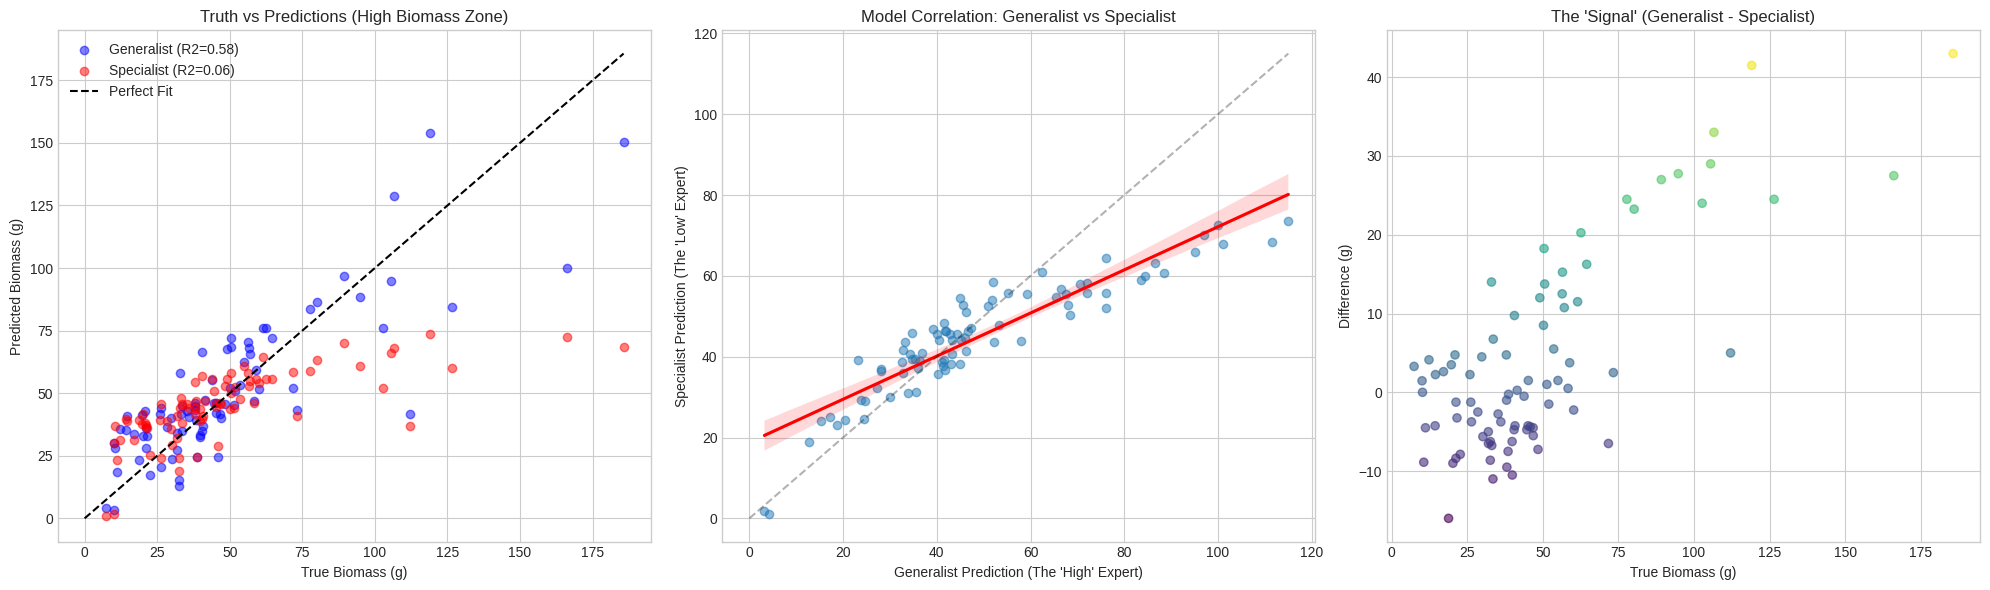

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# y_true = labels[:, 4]
# pred_gen = pred_gen[:, 4]
# pred_spec = pred_spec[:, 4]

pred_corrected = pred_gen.copy()
gap_all = (pred_gen**2 - pred_spec**2)

# Apply correction only to high mass
mask = pred_gen > 100
pred_corrected[mask] = pred_gen[mask] + (0.005 * gap_all[mask])

# --- CONFIGURATION ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- PLOT 1: The "Truth" Check (Biomass vs Predictions) ---
# Goal: See if Specialist hits a "ceiling" or just has a lower slope.
axes[0].scatter(y_true, pred_corrected, alpha=0.5, label='Generalist (R2=0.58)', color='blue')
axes[0].scatter(y_true, pred_spec, alpha=0.5, label='Specialist (R2=0.06)', color='red')
axes[0].plot([0, max(y_true)], [0, max(y_true)], 'k--', label='Perfect Fit')

axes[0].set_title("Truth vs Predictions (High Biomass Zone)")
axes[0].set_xlabel("True Biomass (g)")
axes[0].set_ylabel("Predicted Biomass (g)")
axes[0].legend()

# --- PLOT 2: The "Agreement" Curve (Generalist vs Specialist) ---
# Goal: This answers your question "If Gen says 80, what does Spec say?"
sns.regplot(x=pred_gen, y=pred_spec, ax=axes[1], 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

axes[1].plot([0, max(pred_gen)], [0, max(pred_gen)], 'k--', alpha=0.3, label='1:1 Line')
axes[1].set_title("Model Correlation: Generalist vs Specialist")
axes[1].set_xlabel("Generalist Prediction (The 'High' Expert)")
axes[1].set_ylabel("Specialist Prediction (The 'Low' Expert)")

# --- PLOT 3: The "Divergence" Signal (Difference vs Truth) ---
# Goal: Does the GAP get bigger as the plant gets bigger?
diff = pred_gen - pred_spec
axes[2].scatter(y_true, diff, c=diff, cmap='viridis', alpha=0.6)
axes[2].set_title("The 'Signal' (Generalist - Specialist)")
axes[2].set_xlabel("True Biomass (g)")
axes[2].set_ylabel("Difference (g)")

plt.tight_layout()
plt.show()

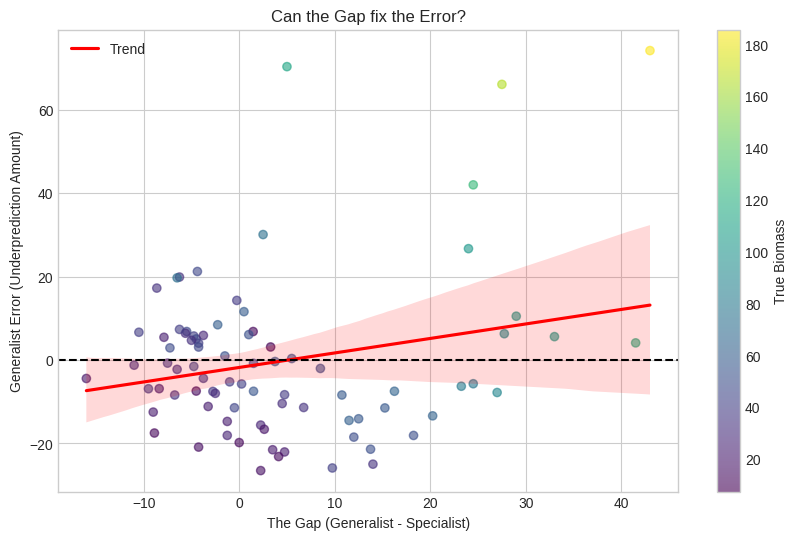

Correlation betwen Gap and Error: 0.2285


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate the Gap (How much bigger is Gen than Spec?)
gap = pred_gen - pred_spec

# 2. Calculate Generalist Residuals (How wrong is the Generalist?)
# Positive value = Generalist is Underpredicting (Target was 100, Gen said 80 -> Error +20)
gen_error = y_true - pred_gen

# 3. The "Money Plot"
plt.figure(figsize=(10, 6))
# Color by True Mass to see if this happens only on big plants
sc = plt.scatter(gap, gen_error, c=y_true, cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='True Biomass')

# Add a trendline to see the correlation
sns.regplot(x=gap, y=gen_error, scatter=False, color='red', label='Trend')

plt.axhline(0, color='black', linestyle='--')
plt.title("Can the Gap fix the Error?")
plt.xlabel("The Gap (Generalist - Specialist)")
plt.ylabel("Generalist Error (Underprediction Amount)")
plt.legend()
plt.show()

# 4. Check the correlation number
correlation = np.corrcoef(gap, gen_error)[0, 1]
print(f"Correlation betwen Gap and Error: {correlation:.4f}")

In [36]:
from sklearn.linear_model import LinearRegression

# 1. Define vectors
# We only want to learn this correction for the "Big" plants where the issue exists.
# Let's trust the Generalist completely for small stuff.
high_mask = pred_gen > 60  # Adjust this threshold if needed (e.g., look at your scatter plot)

gap_train = (pred_gen - pred_spec)[high_mask].reshape(-1, 1)
error_train = (y_true - pred_gen)[high_mask] # The amount we missed by

# 2. Fit the correction
corrector = LinearRegression(fit_intercept=False) # We assume if Gap is 0, Error is 0
corrector.fit(gap_train, error_train)

slope = corrector.coef_[0]

print(f"--- FOUND THE CORRECTION ---")
print(f"Slope (m): {slope:.4f}")
print(f"Logic: If Gen > 40, Add {slope:.4f} * (Gen - Spec) to the prediction.")

# 3. Verify on Fold 0 (Did R2 go up?)
pred_corrected = pred_gen.copy()
gap_all = pred_gen - pred_spec

# Apply correction only to high mass
mask = pred_gen > 60
pred_corrected[mask] = pred_gen[mask] + (slope * gap_all[mask])

from sklearn.metrics import r2_score
print(f"Original R2:  {r2_score(y_true, pred_gen):.5f}")
print(f"Corrected R2: {r2_score(y_true, pred_corrected):.5f}")

--- FOUND THE CORRECTION ---
Slope (m): 0.4036
Logic: If Gen > 40, Add 0.4036 * (Gen - Spec) to the prediction.
Original R2:  0.66671
Corrected R2: 0.68883


In [6]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from torch.utils.data import DataLoader

# --- CONFIGURATION ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 64

def extract_features_and_targets(model, loader, device):
    """
    Runs the dataset through the frozen backbone to extract:
    1. Features (The 300-dim vector)
    2. Targets (The 5 ground truth values, if they exist)
    """
    model.eval()
    model.to(device)
    
    all_features = []
    all_targets = []
    
    print(f"--- Extracting Features ({len(loader.dataset)} images) ---")
    
    with torch.no_grad():
        for batch in tqdm(loader):
            # 1. Unpack Batch (Adjust this line to match your specific DataLoader structure)
            # Example: images, targets, meta = batch
            left, right = batch[0], batch[1]
            targets=None
            if len(batch)==3:
                targets = batch[2] # Test set might not have targets
            
            left = left.to(device)
            right = right.to(device)
            
            # 2. Get Features from Backbone
            # If your model.forward() returns the final 5 predictions, 
            # you must change this to call specific layer or .forward_features()
            # Example for timm models: features = model.forward_features(images)
            # Example for custom: features = model.backbone(images)
            
            # Assuming 'model' here is set to output the 300-dim embedding:
            fl = model.backbone(left)
            fr = model.backbone(right)

            features = torch.cat([fl, fr], dim=1)
            
            # Flatten if necessary (e.g. [B, 300, 1, 1] -> [B, 300])
            if len(features.shape) > 2:
                features = torch.flatten(features, 1)
                
            all_features.append(features.cpu().numpy())
            
            if targets is not None:
                all_targets.append(targets.cpu().numpy())
                
    # Concatenate all batches
    X = np.concatenate(all_features, axis=0)
    
    y = None
    if len(all_targets) > 0:
        y = np.concatenate(all_targets, axis=0)
        
    return X, y

def train_and_predict_ridge(X_train, y_train, X_test):
    """
    Trains a Ridge Regressor on extracted features.
    Uses Log-Transform on targets to handle extrapolation better.
    """
    print(f"\n--- Training Ridge Regressor ---")
    print(f"Train Features: {X_train.shape}")
    print(f"Train Targets:  {y_train.shape}")
    
    # 1. Log-Transform Targets (Crucial for Extrapolation)
    # This helps the linear model predict values higher than max(train)
    y_train_log = np.log1p(y_train)
    
    # 2. Train Ridge
    # MultiOutputRegressor wraps Ridge to handle 5 targets seamlessly
    # alpha=1.0 is standard L2 regularization. Increase if overfitting.
    regressor = MultiOutputRegressor(Ridge(alpha=1.0))
    regressor.fit(X_train, y_train_log)
    
    # 3. Predict on Test
    print("Predicting on Test Set...")
    preds_log = regressor.predict(X_test)
    
    # 4. Inverse Log Transform
    preds_final = np.expm1(preds_log)
    
    return preds_final, regressor

# --- AUTOMATIC SCALING ("The Hidden Gain Finder") ---

def calculate_biomass_shift_ratio(X_train, y_train_biomass, X_test):
    """
    Calculates the 'Intensity Ratio' between Train and Test.
    If Test images have 'stronger' features than Train, this returns > 1.0.
    
    y_train_biomass: Should be just the main biomass column (e.g. column 0)
    """
    print("\n--- Calculating Domain Shift Scalar ---")
    
    # 1. Find the "Growth Direction" in feature space
    # (Simple linear regression to find which features correlate with mass)
    from sklearn.linear_model import LinearRegression
    finder = LinearRegression(fit_intercept=False)
    finder.fit(X_train, y_train_biomass)
    growth_vector = finder.coef_ # Shape: [300]
    
    # 2. Project Train and Test onto this vector
    # This gives us a single "Biomass Intensity Score" for every image
    train_scores = X_train @ growth_vector
    test_scores  = X_test  @ growth_vector
    
    # 3. Compare the Peaks (Top 10% or 5%)
    # We compare the "thickest grass" in Train vs "thickest grass" in Test
    train_peak = np.percentile(train_scores, 95)
    test_peak  = np.percentile(test_scores, 95)
    
    ratio = test_peak / (train_peak + 1e-6)
    
    print(f"Train Peak Intensity: {train_peak:.4f}")
    print(f"Test Peak Intensity:  {test_peak:.4f}")
    print(f"Calculated Multiplier: {ratio:.4f}")
    
    return ratio

# --- MAIN EXECUTION BLOCK ---

# 1. Setup DataLoaders
# train_loader = ...
# test_loader = ...

# 2. Extract
# Ensure 'model' is in feature-extraction mode (returns 300-dim)
X_train, y_train = extract_features_and_targets(model, train_loader, DEVICE)
X_test, _        = extract_features_and_targets(model, test_loader, DEVICE)

# 3. Train Head & Predict
# preds, model_head = train_and_predict_ridge(X_train, y_train, X_test)

--- Extracting Features (285 images) ---


100%|██████████| 285/285 [00:19<00:00, 14.66it/s]


--- Extracting Features (72 images) ---


100%|██████████| 3/3 [00:06<00:00,  2.05s/it]


In [7]:
# 4. Apply The "Hidden Gain" Scaling
# We use the first target column (Biomass) to calculate the shift
biomass_col_idx = 4
scaler = calculate_biomass_shift_ratio(X_train, y_train[:, biomass_col_idx], X_test)
print(scaler)
# # Logic: Only scale if the math says the test set is drastically different (>1.05 or <0.95)
# if scaler > 1.05:
#     print(f"Applying Scalar {scaler:.2f} to predictions (Extrapolation detected)")
#     preds = preds * scaler
# else:
#     print(f"Scalar {scaler:.2f} is close to 1.0. No scaling applied.")

# 5. Save/Use Preds
# print("Final Predictions Shape:", preds.shape)


--- Calculating Domain Shift Scalar ---
Train Peak Intensity: 58.3882
Test Peak Intensity:  82.4810
Calculated Multiplier: 1.4126
1.4126306


In [9]:
model.eval()
running_loss = 0.0
preds = {'total':[], 'gdm':[], 'green':[]}
all_labels = []
device = CFG.DEVICE
for l, r, lab in tqdm(test_loader, desc='valid', leave=False):
    l, r, lab = l.to(device, non_blocking=True), r.to(device, non_blocking=True), lab.to(device, non_blocking=True)
    with torch.no_grad():
        (p_tot, p_gdm, p_green) = model(l, r)

    preds['total'].extend(p_tot.cpu().float().numpy().ravel())
    preds['gdm'].extend(p_gdm.cpu().float().numpy().ravel())
    preds['green'].extend(p_green.cpu().float().numpy().ravel())
    all_labels.extend(lab.cpu().float().numpy())
    
pred_total = np.array(preds['total'])
pred_gdm   = np.array(preds['gdm'])
pred_green = np.array(preds['green'])
true_labels = np.stack(all_labels)  # (N, 5)

# Compute derived
pred_clover = np.clip(pred_gdm - pred_green, 0, None)
pred_dead   = np.clip(pred_total - pred_gdm, 0, None)

# Stack predictions in correct order
pred_all = np.stack([
    pred_green,      # Dry_Green_g
    pred_dead,       # Dry_Dead_g
    pred_clover,     # Dry_Clover_g
    pred_gdm,        # GDM_g
    pred_total       # Dry_Total_g
], axis=1)

In [15]:
print(global_weighted_r2_score(true_labels, 1.5*pred_all))

0.711460406738963


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm


model.eval()
device = CFG.DEVICE
# Helper to extract all features/targets from a loader
def extract_data(loader, name):
    features_list = []
    targets_list = []
    months = []
    print(f"Extracting {name} features...")
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            # Unpack your batch (adjust indices if your loader returns different stuff)
            # Assuming: images, aux_data, labels
            l = batch[0].to(device)
            r = batch[1].to(device)
            labels = batch[2].to(device) 
            month = batch[3]
            
            # Get backbone features only (before the head)
            # If model.backbone() returns a class token or pooled feat, use that.
            fl = model.backbone(l) 
            fr = model.backbone(r) 
            feats = torch.cat([fl, fr], dim=1)
            
            features_list.append(feats.cpu().numpy())
            targets_list.append(labels.cpu().numpy())
            months.append(month)

    return np.concatenate(features_list), np.concatenate(targets_list), np.concatenate(months)

# 1. Get Data
X_train, Y_train_all, months_tr = extract_data(train_loader, "Train")
X_val, Y_val_all, months_val     = extract_data(test_loader, "Val")

Extracting Train features...


Extracting Val features...


In [6]:
# Select the specific Biomass column (Adjust index if needed, e.g. 4 for Dry_Total)
y_train = Y_train_all[:, 4] 
y_val   = Y_val_all[:, 4]

print("Running Analysis...")

# 2. PCA (Fit on Train+Val to see shared space)
X_all = np.concatenate([X_train, X_val])
pca = PCA(n_components=3)
X_pca_all = pca.fit_transform(X_all)

# Split back
X_train_pca = X_pca_all[:len(X_train)]
X_val_pca   = X_pca_all[len(X_train):]

# 3. Best Neuron Search (Fit on Train only)
correlations = [np.corrcoef(X_train[:, i], y_train)[0, 1] for i in range(X_train.shape[1])]
best_idx = np.argmax(np.abs(correlations))
print(f"Most correlated feature is Index #{best_idx} (Corr: {correlations[best_idx]:.3f})")

import plotly.graph_objects as go
import numpy as np

def plot_interactive_3d_unified(X_train_pca, X_val_pca, y_train, y_val):
    
    # 1. Calculate GLOBAL Limits so colors match exactly
    # We combine them to find the absolute min and max across everything
    all_y = np.concatenate([y_train, y_val])
    g_min = all_y.min()
    g_max = np.percentile(all_y, 99) # Using 99th percentile to avoid one huge outlier ruining the scale
    
    # 2. Create the Train Scatter
    trace_train = go.Scatter3d(
        x=X_train_pca[:, 0],
        y=X_train_pca[:, 1],
        z=X_train_pca[:, 2],
        mode='markers',
        name='Train Data',
        marker=dict(
            size=3,
            color=y_train,
            colorscale='Viridis',
            cmin=g_min,     # <--- FORCE MIN
            cmax=g_max,     # <--- FORCE MAX
            opacity=0.4,
            # We remove the colorbar here to avoid duplicates
        ),
        text=[f"Mass: {m:.1f}g" for m in months_tr],
    )

    # 3. Create the Val Scatter
    trace_val = go.Scatter3d(
        x=X_val_pca[:, 0],
        y=X_val_pca[:, 1],
        z=X_val_pca[:, 2],
        mode='markers',
        name='Validation Data',
        marker=dict(
            size=3,
            symbol='diamond',
            color=y_val,
            colorscale='Viridis',
            cmin=g_min,     # <--- SAME MIN
            cmax=g_max,     # <--- SAME MAX
            opacity=0.9,
            line=dict(color='black', width=1),
            colorbar=dict(title='Biomass (g)', x=0.8) # Keep colorbar only here
        ),
        text=[f"Mass: {m:.1f}g" for m in months_val],
    )

    # 4. Combine and Layout
    fig = go.Figure(data=[trace_train, trace_val])

    fig.update_layout(
        title=f"3D Feature Space (Unified Color Scale: {g_min:.0f}g - {g_max:.0f}g)",
        scene=dict(
            xaxis_title='PC 1',
            yaxis_title='PC 2',
            zaxis_title='PC 3',
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        legend=dict(x=0.1, y=0.9)
    )

    fig.show()

# Run it
plot_interactive_3d_unified(X_train_pca, X_val_pca, y_train, y_val)

Running Analysis...
Most correlated feature is Index #26 (Corr: 0.610)


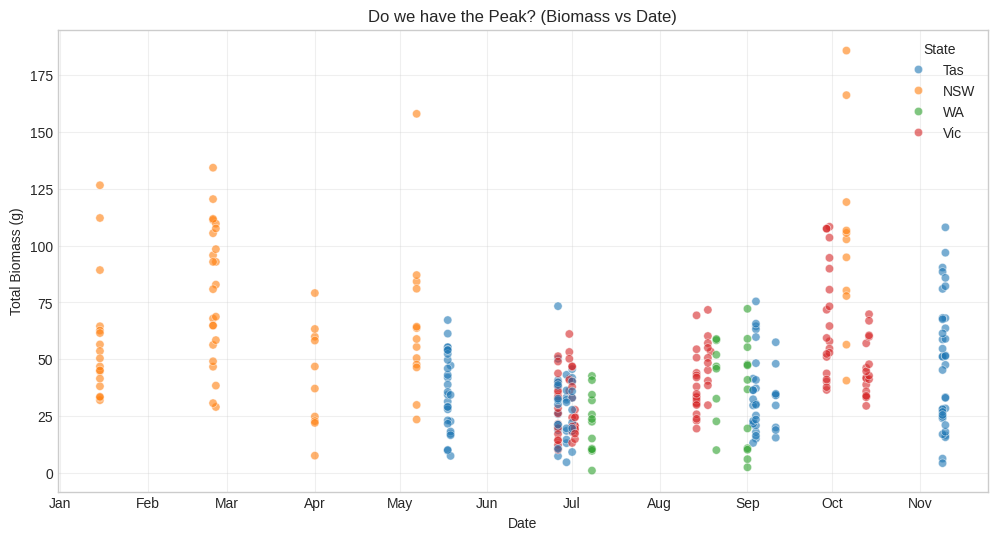

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

# 1. Setup Data
df_wide['Sampling_Date'] = pd.to_datetime(df_wide['Sampling_Date'])
# Extract Day of Year (1-365) to compare different years easily
df_wide['DayOfYear'] = df_wide['Sampling_Date'].dt.dayofyear 

plt.figure(figsize=(12, 6))

# 2. Plot Biomass vs Date
# We color by 'State' because Tasmania peaks later than WA
sns.scatterplot(data=df_wide, x='Sampling_Date', y='Dry_Total_g', hue='State', alpha=0.6)

# 3. Format the X-Axis to show months clearly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.title("Do we have the Peak? (Biomass vs Date)")
plt.xlabel("Date")
plt.ylabel("Total Biomass (g)")
plt.grid(True, alpha=0.3)
plt.show()

In [1]:
import gc
torch.cuda.empty_cache()
gc.collect()
del model, train_loader, val_loader, optimizer, main_scheduler

NameError: name 'torch' is not defined

## Cross Validation Training

In [ ]:
import pandas as pd
import gc
from datetime import datetime
from sklearn.model_selection import StratifiedGroupKFold
from configs.cfg import CFG
from torch.amp import GradScaler
from dataset.biomass_dataset import *
from utils.augs import *
from configs.deterministic import *
from models.models import *
from train.train import *
from dataset.preprocess_data import *
from utils.utils import *

if __name__ == "__main__":
    set_seed(CFG.SEED, CFG.DETERMINISTIC)
    df_wide = get_df()
    # best_seed = find_best_seed(df_wide, 1000)
    sgkf = StratifiedGroupKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
    splitter = sgkf.split(X=df_wide, y=df_wide['biomass_bin'], groups=df_wide['group'])

    # check_splits(splitter, df_wide)
    # Store the best R2 score from each fold
    all_fold_best_scores = []
    group_name = f"Date_{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
    for fold, (tr_idx, val_idx) in enumerate(splitter):
        print('\n' + '='*70)
        print(f'   FOLD {fold+1}/{CFG.N_FOLDS}   |   {len(tr_idx)} train / {len(val_idx)} val')
        print('='*70)
        
        # print(tr_idx)
        # print(val_idx)

        tr_df  = df_wide.iloc[tr_idx].reset_index(drop=True)
        val_df = df_wide.iloc[val_idx].reset_index(drop=True)

        best_r2 = train_base(tr_df,val_df,fold,group_name = group_name)
        all_fold_best_scores.append(best_r2)

    # Cleanup
    torch.cuda.empty_cache()
    gc.collect()
    all_fold_sizes = [83,81,66,71,56]# Change by hand if folds change date
    # all_fold_sizes = [76,74,90,57,60]# Change by hand if folds change state+date
    weighted_cv_score = np.average(all_fold_best_scores, weights=all_fold_sizes)

    # 2. Standard Deviation
    # For std, a simple np.std is usually fine to just show "stability," 
    # but you can stick to the simple calculation for this.
    std_cv_score = np.std(all_fold_best_scores)
    print('\n' + '='*70)
    print('         FINAL CROSS-VALIDATION SCORE')
    print('='*70)
    print(f'Public LB Score: 0.58')
    # Notice we use the weighted score here
    print(f'Local CV Score: {weighted_cv_score:.4f} ± {std_cv_score:.4f}')
    print('\nIndividual Fold Scores:')
    for i, (score, size) in enumerate(zip(all_fold_best_scores, all_fold_sizes)):
        print(f'  Fold {i+1} (n={size}): {score:.4f}')

/home/teo/kaggle/csiro/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data...
357 training images

   FOLD 1/5   |   274 train / 83 val
Building model...
vit_small_patch16_dinov3 parameters: 21586944
Pretrained weights loaded (CPU)
Freezing backbone parameters.


wandb: Currently logged in as: butnaruteodor (butnaruteodor-universitatea-tehnic-gheorghe-asachi-din-ia-i) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


train:   0%|          | 0/274 [00:00<?, ?it/s]/home/teo/kaggle/csiro/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/teo/kaggle/csiro/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:132: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch 01 | TrainLoss 1761.89731 | ValLoss 2279.79931 | ValR² -1.1948 (BEST)
SAVED (R²: -1.1948)


...

Epoch 50 | TrainLoss 109.75655 | ValLoss 112.45467 | ValR² 0.8458 (BEST)
SAVED (R²: 0.8458)


Epoch 52 | TrainLoss 124.37473 | ValLoss 111.33667 | ValR² 0.8480 (BEST)
SAVED (R²: 0.8480)


EARLY STOP (no improvement in 15 epochs)


best_r2,▁▇██████████████████████████████████████
test_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_val_r2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▃▅▄▂▄▂▃▂▁▃▂▃▃▂▂▁▂▁▂▁▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
val_r2,▁▇█▇████▇███████████████████████████████
best_r2,0.84804
test_loss,0
test_val_r2,0
train_loss,94.09284
val_loss,133.10072



         FINAL CROSS-VALIDATION SCORE
Public LB Score: 0.58
Local CV Score: 0.7677 ± 0.0505

Individual Fold Scores:
  Fold 1 (n=83): 0.7286
  Fold 2 (n=81): 0.7482
  Fold 3 (n=66): 0.8192
  Fold 4 (n=71): 0.7242
  Fold 5 (n=56): 0.8480


In [2]:
import timm

# This lists all DINOv3 variants available in your version
models = timm.list_models('*dinov3*')
for m in models:
    print(m)

vit_7b_patch16_dinov3
vit_base_patch16_dinov3
vit_base_patch16_dinov3_qkvb
vit_huge_plus_patch16_dinov3
vit_huge_plus_patch16_dinov3_qkvb
vit_large_patch16_dinov3
vit_large_patch16_dinov3_qkvb
vit_small_patch16_dinov3
vit_small_patch16_dinov3_qkvb
vit_small_plus_patch16_dinov3
vit_small_plus_patch16_dinov3_qkvb


In [34]:
# Filter train.csv to get only val_df images
df_long_full = pd.read_csv(os.path.join('csiro-biomass', 'train.csv'))

# Get the set of image paths in val_df
val_image_paths = set(val_df['image_path'].values)

# Filter to keep only rows where image_path is in val_df
val_df_long = df_long_full[df_long_full['image_path'].isin(val_image_paths)].reset_index(drop=True)

# Save to CSV in the same format as train.csv
val_df_long.to_csv(os.path.join('csiro-biomass', 'val.csv'), index=False)

print(f"✅ Saved val.csv with {len(val_df_long)} rows ({len(val_image_paths)} unique images)")
print(f"Columns: {val_df_long.columns.tolist()}")
print(f"\nFirst few rows:")
print(val_df_long.head(10))

✅ Saved val.csv with 415 rows (83 unique images)
Columns: ['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'target_name', 'target']

First few rows:
                    sample_id              image_path Sampling_Date State  \
0  ID1070112260__Dry_Clover_g  train/ID1070112260.jpg     2015/1/15   NSW   
1    ID1070112260__Dry_Dead_g  train/ID1070112260.jpg     2015/1/15   NSW   
2   ID1070112260__Dry_Green_g  train/ID1070112260.jpg     2015/1/15   NSW   
3   ID1070112260__Dry_Total_g  train/ID1070112260.jpg     2015/1/15   NSW   
4         ID1070112260__GDM_g  train/ID1070112260.jpg     2015/1/15   NSW   
5  ID1078930021__Dry_Clover_g  train/ID1078930021.jpg     2015/6/26   Vic   
6    ID1078930021__Dry_Dead_g  train/ID1078930021.jpg     2015/6/26   Vic   
7   ID1078930021__Dry_Green_g  train/ID1078930021.jpg     2015/6/26   Vic   
8   ID1078930021__Dry_Total_g  train/ID1078930021.jpg     2015/6/26   Vic   
9         ID1078930021__GDM_g  